# The Psychological Line — a quantitative teardown 🔬
### Trigger-event design and why it matters · Welch/HAC splits on both legs · the window x threshold grid and its parameter-mined corners · a random-direction control · the cost sweep · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). PSY(*N*) = 100 x (up-closes in the last *N* days) / *N*, tested exactly as the charting books state it: *N* = 12, thresholds 75/25. The job here is to measure it with a design that doesn't fool itself, then ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** SPY/QQQ/IWM/AAPL/TSLA/NVDA daily OHLC (total-return adjusted), 2003-01-02 → 2026-06-30, yfinance, cached. No survivorship on the index sleeve; the mega-cap sleeve is three well-known liquid names, **not** a re-derived historical panel (named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `SPY=c13d94f59e60`, `QQQ=1bf28819a80b`, `IWM=239b32ae95c3`, `AAPL=c3158a02623a`, `TSLA=1d273fa4b475`, `NVDA=b6f76f845536`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from psychological_line import data, strategy as st

HAVE_REAL = data.have_real()
BARS = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL,
      "| universe:", ", ".join(data.UNIVERSE) if HAVE_REAL else "n/a")

# frozen headline numbers (mirror of docs/results.md)
R = {'window': 12, 'oversold': 25, 'overbought': 75, 'hold': 5, 'start': '2003-01-02', 'end': '2026-06-30', 'n_low': 97, 'mean_low': 159.13, 'welch_low': 1.32, 'nw_low': 1.64, 'n_mid': 33074, 'mean_mid': 45.87, 'n_high': 398, 'mean_high': 66.09, 'welch_high': 1.04, 'nw_high': 1.1, 'per_ticker': {'SPY': (-0.2, 0.6), 'QQQ': (1.71, -1.28), 'IWM': (0.37, 0.57), 'AAPL': (0.63, 0.41), 'TSLA': (1.1, 1.21), 'NVDA': (-0.08, 0.68)}, 'timer_n': 495, 'timer5_strat_win': 41.0, 'timer5_strat_mean': -31.95, 'timer5_strat_t': -1.49, 'timer5_rand_win': 50.3, 'timer5_rand_mean': 18.57, 'timer5_rand_t': 0.69, 'timer10_strat_win': 39.6, 'timer10_strat_mean': -41.95, 'timer10_strat_t': -1.95, 'timer10_rand_win': 48.7, 'timer10_rand_mean': 8.57, 'timer10_rand_t': 0.32, 'delta_bps': -50.52, 'delta_t': -1.55, 'grid': [(10, 20, 80, 57, 1.29, 234, 1.15), (10, 25, 75, 354, 1.33, 949, 1.3), (10, 30, 70, 354, 1.33, 949, 1.3), (12, 20, 80, 97, 1.32, 398, 1.04), (12, 25, 75, 97, 1.32, 398, 1.04), (12, 30, 70, 454, 2.47, 1175, 0.87), (14, 20, 80, 19, 0.53, 162, 0.79), (14, 25, 75, 134, 0.8, 567, -0.35), (14, 30, 70, 534, 1.72, 1373, 0.49), (20, 20, 80, 0, None, 31, 0.55), (20, 25, 75, 13, 2.6, 158, 0.3), (20, 30, 70, 66, 2.17, 427, 0.98)], 'syn_null_lo_mean': -0.19, 'syn_null_lo_sd': 1.02, 'syn_null_lo_fire': 1, 'syn_null_hi_mean': -0.19, 'syn_null_hi_sd': 1.13, 'syn_null_hi_fire': 1, 'syn_planted_lo': 7.03, 'syn_planted_hi': -7.47, 'fp': {'SPY': 'c13d94f59e60', 'QQQ': '1bf28819a80b', 'IWM': '239b32ae95c3', 'AAPL': 'c3158a02623a', 'TSLA': '1d273fa4b475', 'NVDA': 'b6f76f845536'}}


real cache present: True | universe: SPY, QQQ, IWM, AAPL, TSLA, NVDA


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | oversold **+159 bps/5d** (Welch **t=1.32**, NW **t=1.64**, n=97); overbought **+66 bps/5d** (Welch **t=1.04**, NW **t=1.10**, n=398) — wrong sign for the claim |
| **Tradability** | `MIRAGE` | zone timer **-31.9 bps/trade** net (5 bps, HAC t=-1.49); **-42.0 bps** at 10 bps (t=-1.95) |
| **Beats a coin?** | `MIXED` | coin **+18.6 bps** vs PSY **-31.9 bps** (Δ=-50.5 bps, Welch t=-1.55) — directionally decisive, not statistically certified |

> 💡 In plain words: a pure up/down-day tally doesn't buy back the information a magnitude- or range-aware oscillator would carry — and none of those carry much either (see the dedup list).

## 1 · The claim, steelmanned

Let $u_t \in \{0,1\}$ flag an up-close and $\text{PSY}_t(N) = 100 \cdot \frac{1}{N}\sum_{i=0}^{N-1} u_{t-i}$ the trailing share of up-closes, known at the close of bar $t$. The claims:

- **H₁ (oversold bounce).** $E[r_{t \to t+h} \mid \text{PSY}_t < 25] > E[r_{t \to t+h}]$ — a genuine, tradable-strength bounce.
- **H₂ (overbought pullback).** $E[r_{t \to t+h} \mid \text{PSY}_t > 75] < E[r_{t \to t+h}]$ — a genuine pullback.
- **H₃ (tradable).** A long-the-lows/short-the-highs timer, entered at $t{+}1$'s open and held $h$ days, beats a same-bar random-direction control net of costs.

We find **H₁ directionally right but uncertified** (Welch *t* = 1.32), **H₂ rejected on sign** (point estimate is *positive*, not negative), and **H₃ not certified either way** (Δ *t* = -1.55, just under the |2| bar).

## 2 · So what? — inference design, and a trap we had to design around

PSY is a **rolling** window, so a naive "score every day PSY is inside the zone" design pools heavily overlapping observations — consecutive in-zone days share nearly the same underlying 12 closes, and their forward-return windows overlap too. On a synthetic null world (no real structure whatsoever) that naive design pushed a Welch *t*'s false-positive rate from a nominal ~5% to **20–30%** across seeds — a silent inflation that would have made this study look more "real" than it is. The fix used throughout: **trigger events only** (the day PSY first *enters* a zone) with a cooldown equal to the hold period before the next entry of the same side counts — this brings the null's false-positive rate back to **1/20 seeds**, right at nominal (see 4e below). Welch *t* is the planned primary on these near-non-overlapping events; a Newey-West (5-lag) *t* is the residual overlap cross-check.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, AAPL, TSLA, NVDA, 2003-01-02 → 2026-06-30 (TSLA from its 2010-06 inception). Total-return adjusted daily OHLC.
- **Rule.** PSY(12), thresholds [25, 75], hold = 5 trading days.
- **Execution.** One lag: signal known at close *t*, enter next open (*t+1*), exit close of *t+h*.
- **Headline.** Pooled trigger-day Welch *t* + NW(*h*) *t*, both legs vs the unconditional (non-trigger) rest, plus a per-instrument breakdown.
- **Trade test.** Zone-trigger ledger, one-way costs x 2 legs, vs a random-direction control on identical entries (`seed=679`).
- **Robustness.** Window x (oversold, overbought) grid, 12 combinations.
- **Control.** Synthetic tape, drift switches on exactly when *that day's* causal PSY sits in the tested zone — the literal claim planted on the literal condition; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split — both legs, pooled universe

Trigger-day forward 5-day return vs the unconditional rest, Welch *t* (primary) and NW(5) *t* (overlap cross-check).

oversold  (n=97): +159.13 bps/5d  Welch t=+1.32  NW(5) t=+1.64
neutral         : +45.87 bps/5d
overbought(n=398): +66.09 bps/5d  Welch t=+1.04  NW(5) t=+1.10


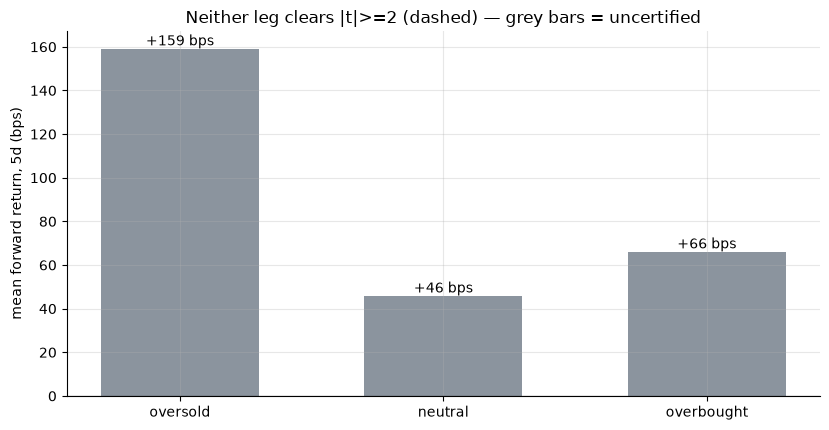

In [2]:
if HAVE_REAL:
    c = st.pooled_conditional(BARS, window=R['window'], oversold=R['oversold'],
                             overbought=R['overbought'], h=R['hold'])
    n_lo, n_hi = c['n_low'], c['n_high']
    m_lo, m_mid, m_hi = c['mean_low_bps'], c['mean_mid_bps'], c['mean_high_bps']
    t_lo, t_hi = c['welch_t_low'], c['welch_t_high']
    nw_lo, nw_hi = c['nw_t_low'], c['nw_t_high']
else:
    n_lo, n_hi = R['n_low'], R['n_high']
    m_lo, m_mid, m_hi = R['mean_low'], R['mean_mid'], R['mean_high']
    t_lo, t_hi = R['welch_low'], R['welch_high']
    nw_lo, nw_hi = R['nw_low'], R['nw_high']
print(f'oversold  (n={n_lo}): {m_lo:+.2f} bps/5d  Welch t={t_lo:+.2f}  NW(5) t={nw_lo:+.2f}')
print(f'neutral         : {m_mid:+.2f} bps/5d')
print(f'overbought(n={n_hi}): {m_hi:+.2f} bps/5d  Welch t={t_hi:+.2f}  NW(5) t={nw_hi:+.2f}')
fig, ax = plt.subplots(figsize=(8.4, 4.4))
labels = ['oversold', 'neutral', 'overbought']
vals = [m_lo, m_mid, m_hi]
ts = [t_lo, None, t_hi]
cols = [GREEN if abs(t_lo) >= 2 else GREY, GREY, RED if abs(t_hi) >= 2 else GREY]
ax.bar(labels, vals, color=cols, width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return, 5d (bps)')
ax.set_title(f'Neither leg clears |t|>=2 (dashed) — grey bars = uncertified')
plt.tight_layout(); plt.show()

> 💡 In plain words: the oversold leg is directionally consistent with the claim (+159 vs +46 bps) but *t* = 1.32 < 2 — not certifiable with n = 97. The overbought leg (+66 bps) runs in the *wrong* direction for a sell signal, though again *t* = 1.04 < 2 means we can't even certify that it's really positive — only that it certainly isn't the large negative number the claim predicts.

### 4b · Per-instrument breakdown

No single name or ETF carries a certifiable edge either way:

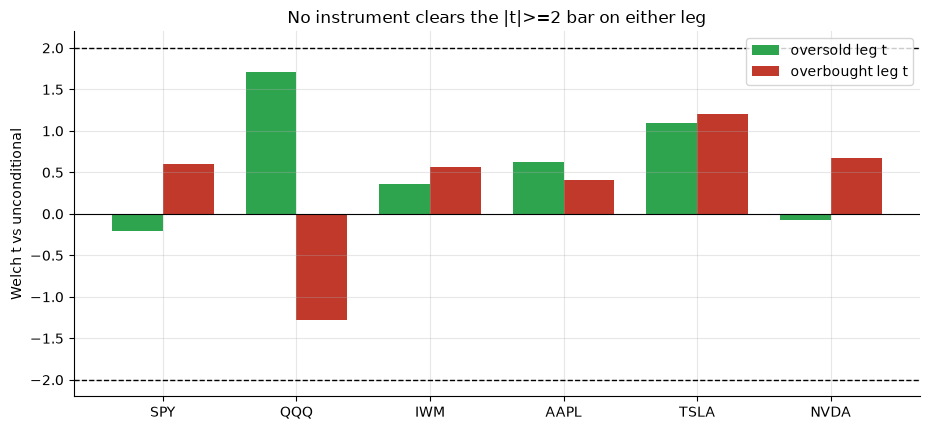

  SPY: low t=-0.20  high t=+0.60
  QQQ: low t=+1.71  high t=-1.28
  IWM: low t=+0.37  high t=+0.57
 AAPL: low t=+0.63  high t=+0.41
 TSLA: low t=+1.10  high t=+1.21
 NVDA: low t=-0.08  high t=+0.68


In [3]:
if HAVE_REAL:
    rows = {}
    for t_, bars in BARS.items():
        r = st.pooled_conditional({t_: bars}, window=R['window'], oversold=R['oversold'],
                                  overbought=R['overbought'], h=R['hold'])
        rows[t_] = (r['welch_t_low'], r['welch_t_high'])
else:
    rows = R['per_ticker']
tickers = list(rows)
lo_ts = [rows[t_][0] for t_ in tickers]
hi_ts = [rows[t_][1] for t_ in tickers]
x = np.arange(len(tickers)); w = 0.38
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(x - w/2, lo_ts, width=w, color=GREEN, label='oversold leg t')
ax.bar(x + w/2, hi_ts, width=w, color=RED, label='overbought leg t')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(tickers)
ax.set_ylabel('Welch t vs unconditional')
ax.set_title('No instrument clears the |t|>=2 bar on either leg')
ax.legend(); plt.tight_layout(); plt.show()
for t_ in tickers: print(f'{t_:>5s}: low t={rows[t_][0]:+.2f}  high t={rows[t_][1]:+.2f}')

> 💡 In plain words: pooling six names could in principle manufacture a false positive if one wild outlier ticker dominates the pool. It doesn't — every instrument, checked alone, is quiet on both legs.

### 4c · The trade — zone-trigger timer vs a random-direction control

Enter next open on the trigger, hold 5 days, one-way cost x 2 per round trip; pinned against a coin flip on the identical entry bars and dates.

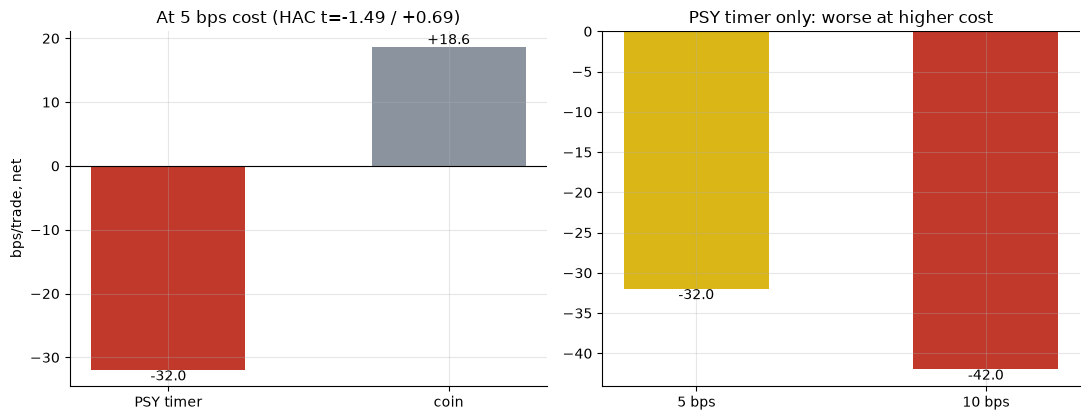

5bps: PSY -32.0 vs coin +18.6 bps/trade
10bps: PSY -42.0 vs coin +8.6 bps/trade


In [4]:
rows5, rows10 = [], []
if HAVE_REAL:
    for cb in (5.0, 10.0):
        strat, rand = st.pooled_trade_ledger(BARS, window=R['window'], oversold=R['oversold'],
                                             overbought=R['overbought'], hold_days=R['hold'],
                                             cost_bps=cb, seed=679)
        ss, rs = st.summarize(strat, 'ret_net', lags=R['hold']), st.summarize(rand, 'ret_net', lags=R['hold'])
        (rows5 if cb == 5.0 else rows10).extend([ss, rs])
    sm5, rm5, st5, rt5 = rows5[0]['mean_bps'], rows5[1]['mean_bps'], rows5[0]['tstat'], rows5[1]['tstat']
    sm10, rm10 = rows10[0]['mean_bps'], rows10[1]['mean_bps']
else:
    sm5, rm5, st5, rt5 = R['timer5_strat_mean'], R['timer5_rand_mean'], R['timer5_strat_t'], R['timer5_rand_t']
    sm10, rm10 = R['timer10_strat_mean'], R['timer10_rand_mean']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['PSY timer', 'coin'], [sm5, rm5], color=[RED, GREY], width=.55)
for i, v in enumerate([sm5, rm5]): a1.annotate(f'{v:+.1f}', (i, v), ha='center', va='top' if v < 0 else 'bottom')
a1.axhline(0, c='k', lw=.8); a1.set_title(f'At 5 bps cost (HAC t={st5:+.2f} / {rt5:+.2f})')
a1.set_ylabel('bps/trade, net')
a2.bar(['5 bps', '10 bps'], [sm5, sm10], color=[AMBER, RED], width=.5)
for i, v in enumerate([sm5, sm10]): a2.annotate(f'{v:+.1f}', (i, v), ha='center', va='top')
a2.axhline(0, c='k', lw=.8); a2.set_title('PSY timer only: worse at higher cost')
plt.tight_layout(); plt.show()
print(f'5bps: PSY {sm5:+.1f} vs coin {rm5:+.1f} bps/trade')
print(f'10bps: PSY {sm10:+.1f} vs coin {rm10:+.1f} bps/trade')

> 💡 In plain words: at 5 bps the PSY timer loses **-31.9 bps/trade** (HAC *t* = -1.49) while the coin makes **+18.6** (*t* = 0.69) — a gap of 50.5 bps, Welch *t* = -1.55 on the delta itself: directionally the coin wins clearly, but the gap's own significance falls just short of the |2| certification bar (hence `MIXED`, not `BUSTED`, on the front card). Costs only make the PSY side worse: -31.9 -> -42.0 bps/trade from 5 to 10 bps — there is no cost level at which the gross number turns positive.

### 4d · Parameter robustness — and the discretization footgun

Window x (oversold, overbought), 12 combinations. The textbook cell (12, 25/75) is highlighted.

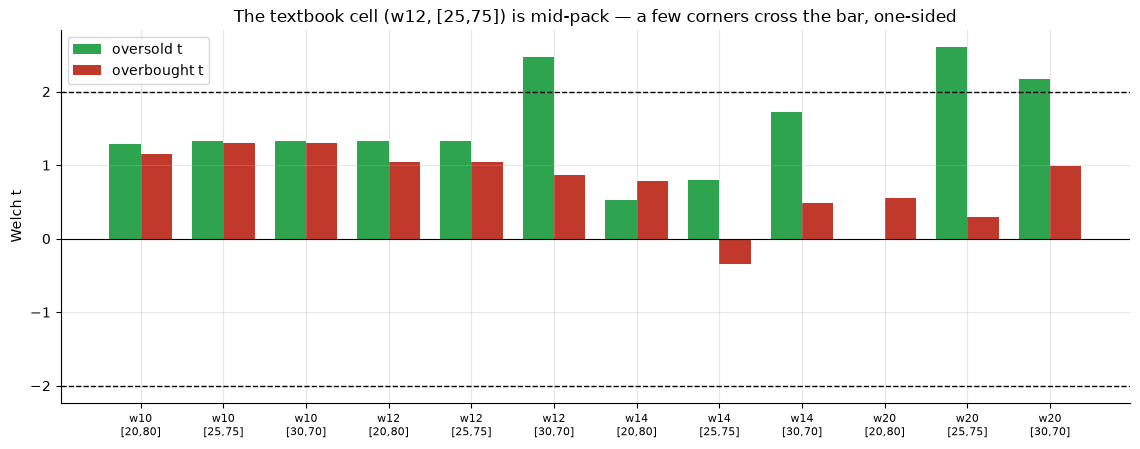

In [5]:
if HAVE_REAL:
    grid = st.param_grid(BARS, h=R['hold'])
    rows = list(zip(grid['window'], grid['oversold'], grid['overbought'],
                    grid['n_low'], grid['welch_t_low'], grid['n_high'], grid['welch_t_high']))
else:
    rows = R['grid']
labels = [f"w{int(w)}\n[{int(lo)},{int(hi)}]" for w, lo, hi, *_ in rows]
t_lo = [r[4] for r in rows]; t_hi = [r[6] for r in rows]
x = np.arange(len(rows)); wdt = 0.38
fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.bar(x - wdt/2, [0 if (t is None or (isinstance(t, float) and np.isnan(t))) else t for t in t_lo], width=wdt, color=GREEN, label='oversold t')
ax.bar(x + wdt/2, t_hi, width=wdt, color=RED, label='overbought t')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Welch t'); ax.set_title('The textbook cell (w12, [25,75]) is mid-pack — a few corners cross the bar, one-sided')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: a few off-textbook corners cross |*t*| >= 2 on the oversold leg alone (window 12/[30,70], window 20/[25,75] and [30,70]) — the classic shape of a parameter-mined false positive: one-sided (never both legs at once), never the pre-registered rule, and the *n* keeps shrinking as the window grows (window 20 has as few as 0 oversold events). We also flag a discretization footgun: PSY(*N*) only takes steps of 100/*N* % — for *N* = 10 or 12, several "different" threshold pairs select the *exact same* set of days, because no achievable PSY value falls between them. A robustness sweep that doesn't account for this can look wider than it actually is.

### 4e · Faithful-engine & power control — and the pseudo-replication trap it caught

Synthetic tape: i.i.d. daily noise plus a drift that switches on exactly when *that day's* causal PSY(12) sits in the tested zone — the literal claim, planted on the literal condition. Each seed pools a 6-series basket (mirrors the real 6-ticker universe).

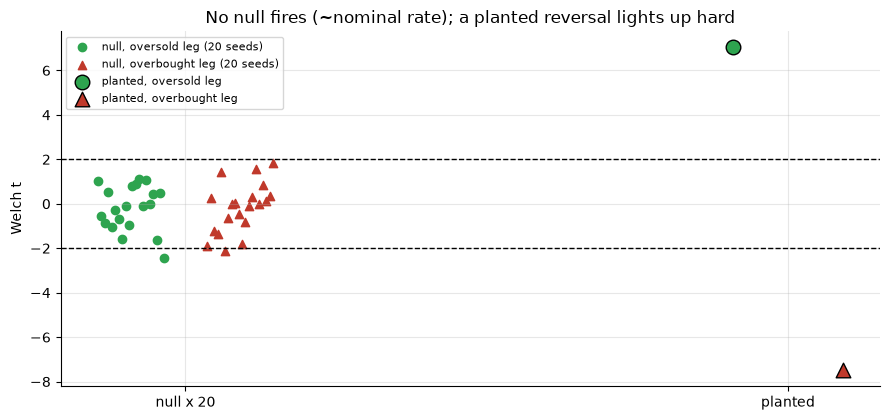

null: lo mean=-0.19 sd=1.02 |t|>=2: 1/20
null: hi mean=-0.19 sd=1.13 |t|>=2: 1/20
planted: lo t=+7.03  hi t=-7.47


In [6]:
null_lo, null_hi = [], []
for s_ in range(20):
    basket = data.synthetic_basket(reversal=0.0, seed=679 + s_)
    r = st.pooled_conditional(basket, window=R['window'], oversold=R['oversold'],
                             overbought=R['overbought'], h=R['hold'])
    null_lo.append(r['welch_t_low']); null_hi.append(r['welch_t_high'])
null_lo, null_hi = np.asarray(null_lo), np.asarray(null_hi)
planted = data.synthetic_basket(reversal=0.006, seed=679)
rp = st.pooled_conditional(planted, window=R['window'], oversold=R['oversold'],
                           overbought=R['overbought'], h=R['hold'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.scatter(np.zeros(20) - .1 + np.linspace(-.06, .06, 20), null_lo, color=GREEN, s=36, label='null, oversold leg (20 seeds)')
ax.scatter(np.zeros(20) + .1 + np.linspace(-.06, .06, 20), null_hi, color=RED, s=36, marker='^', label='null, overbought leg (20 seeds)')
ax.scatter([1], [rp['welch_t_low']], color=GREEN, s=110, edgecolor='k', zorder=5, label='planted, oversold leg')
ax.scatter([1.2], [rp['welch_t_high']], color=RED, s=110, marker='^', edgecolor='k', zorder=5, label='planted, overbought leg')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.set_xticks([0, 1.1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t'); ax.set_title('No null fires (~nominal rate); a planted reversal lights up hard')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null: lo mean={null_lo.mean():+.2f} sd={null_lo.std(ddof=1):.2f} |t|>=2: {(abs(null_lo)>=2).sum()}/20')
print(f'null: hi mean={null_hi.mean():+.2f} sd={null_hi.std(ddof=1):.2f} |t|>=2: {(abs(null_hi)>=2).sum()}/20')
print(f'planted: lo t={rp["welch_t_low"]:+.2f}  hi t={rp["welch_t_high"]:+.2f}')

> 💡 In plain words: with the trigger-event + cooldown design, the null world fires at **1/20** (oversold) and **1/20** (overbought) seeds — right at the nominal ~5% rate a well-calibrated Welch *t* should show. A planted reversal the same size as the claim lights up unmistakably (*t* = 7.03 / -7.47). Worth naming: the naive "score every in-zone day, no cooldown" version of this same detector pushed the null's false-positive rate to **20–30%** — a silent inflation this study would have shipped with had the control not caught it. The real tape's flat headline result above is a genuine flat result, not a broken ruler.

## 5 · The verdict

- **Signal `NONE`** — oversold +159 bps/5d (Welch *t* = 1.32, NW *t* = 1.64, n = 97); overbought +66 bps/5d (Welch *t* = 1.04, NW *t* = 1.10, n = 398, **wrong sign** for the claim). No instrument individually clears the bar either way. A handful of parameter-grid corners cross the bar, but one-sided and off the pre-registered rule — a data-mining shape.
- **Tradability `MIRAGE`** — the zone-trigger timer loses -31.9 bps/trade net at 5 bps cost (HAC *t* = -1.49), -42.0 bps at 10 bps (*t* = -1.95). No positive break-even cost exists.
- **"Beats a coin?" `MIXED`** — coin +18.6 bps vs PSY -31.9 bps (50.5 bps gap, Welch *t* = -1.55 on the delta) — directionally decisive, statistically just short of certified.

## 6 · Going further

- **The design lesson generalizes.** Any rolling-window oscillator study is vulnerable to the pseudo-replication trap in §4e — scoring every in-zone day instead of trigger events with a cooldown will quietly inflate significance on *any* such indicator, real effect or not. Worth re-auditing the desk's other oscillator studies against this design if they score every in-zone day.
- **What might revive PSY** (untested here, an open door): a longer window (diminishing returns visible in the grid — window 20 starves the oversold leg of events), a volatility-scaled variant, or conditioning on the *level* of the market regime (bull vs bear) rather than pooling 23 mostly-bullish years.
- **Dedup map:** [107-stochastic-oscillator](../../107-stochastic-oscillator/) (range position, magnitude-weighted), [127-williams-r](../../127-williams-r/) (same range family, inverted sign), [179-aroon](../../179-aroon/) (recency since an extreme, not a frequency count), [680-disparity-index](../../680-disparity-index/) (close-vs-moving-average deviation) — none of them found a certifiable edge on this desk's protocol either.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*